# Gaussian Naive Bayes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Mock Data Generation

In [ ]:
def generate_gaussian_data(n_samples=300):
    X1 = np.random.normal(loc=0, scale=3, size=(100, 5))
    X2 = np.random.normal(loc=3, scale=1.5, size=(100, 5))
    X3 = np.random.normal(loc=-3, scale=0.8, size=(100, 5))
    
    X = np.vstack([X1, X2, X3])
    y = np.array([0]*100 + [1]*100 + [2]*100)
    
    columns = [f"Feature_{i+1}" for i in range(5)]
    df = pd.DataFrame(X, columns=columns)
    df['Target'] = y
    return df, X, y

df, X, y = generate_gaussian_data()
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Target
0,2.633300,0.778972,-1.772771,2.631967,4.462430,0
1,-6.440478,0.535565,-0.508885,-5.208774,-1.993282,0
2,0.241978,5.355353,3.041924,3.005640,0.729628,0
3,4.142137,0.337339,3.461817,-4.202206,7.045994,0
4,0.926744,-0.798629,-3.067052,1.386594,0.834459,0


## 2. Implementation

Gaussian Probability Density Function: $P(x|y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} e^{-\frac{(x-\mu_y)^2}{2\sigma_y^2}}$

In [ ]:
class GaussianNaiveBayes:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        self.mean = np.zeros((n_classes, n_features))
        self.var = np.zeros((n_classes, n_features))
        self.priors = np.zeros(n_classes)

        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.mean[idx, :] = X_c.mean(axis=0)
            self.var[idx, :] = X_c.var(axis=0)
            self.priors[idx] = X_c.shape[0] / float(n_samples)

    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        posteriors = []

        for idx, c in enumerate(self.classes):
            
            # Calculate log of prior to avoid underflow
            prior = np.log(self.priors[idx])
            
            # Sum of log of class conditional probabilities
            conditional = np.sum(np.log(self._pdf(idx, x)))
            posterior = prior + conditional
            posteriors.append(posterior)
            
        return self.classes[np.argmax(posteriors)]

    def _pdf(self, class_idx, x):
        mean = self.mean[class_idx]
        var = self.var[class_idx]

        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

## 3. Training and Visualization

[[ 0.22329304  0.01683137 -0.43946051  0.59982724 -0.03715757]
 [ 3.1269842   2.96814495  3.00511414  3.16633517  2.81966579]
 [-3.01199173 -2.93868178 -2.89920538 -3.00409415 -3.02600316]] [[12.28035162  6.952231    9.42903086  7.79665648  8.33854508]
 [ 2.09088604  2.14018846  2.10661489  2.02315699  2.49098174]
 [ 0.53612027  0.53948609  0.68666685  0.6516571   0.63339198]] [0.33333333 0.33333333 0.33333333]
Accuracy: 97.33%


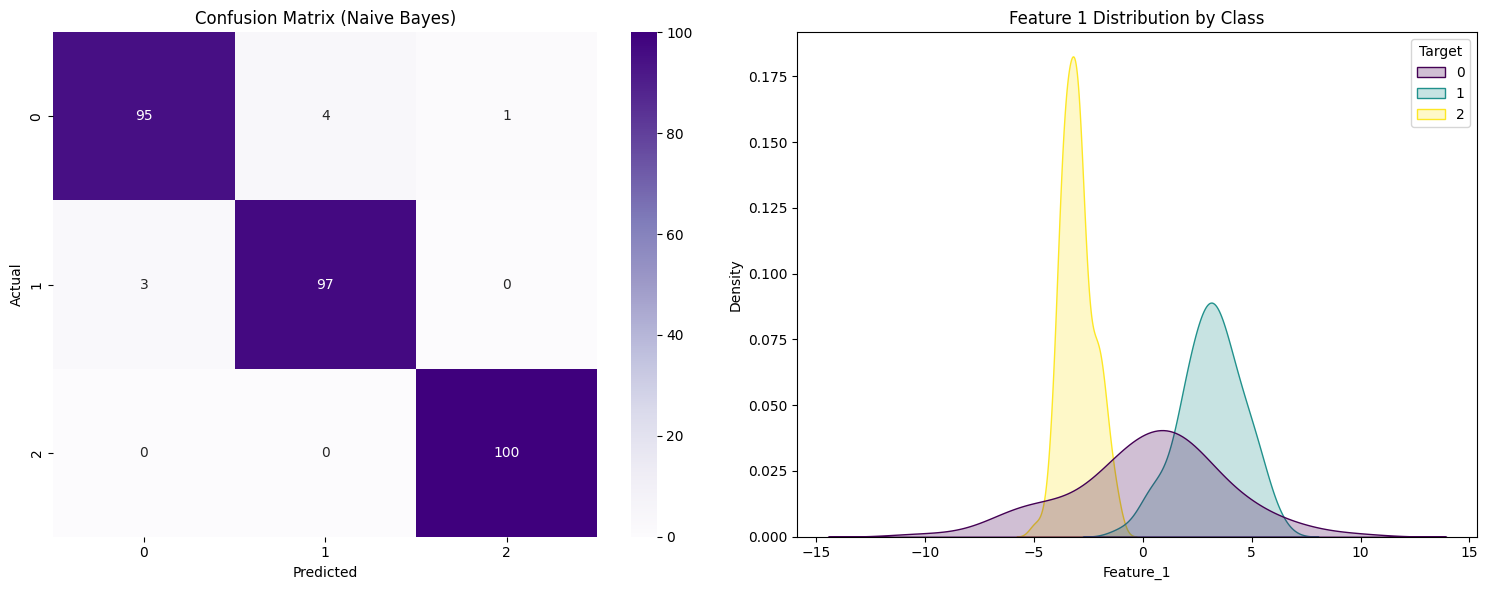

In [14]:
model = GaussianNaiveBayes()
model.fit(X, y)
print(model.mean, model.var, model.priors)

y_pred = model.predict(X)
print(f"Accuracy: {np.mean(y == y_pred) * 100:.2f}%")

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
results_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
sns.heatmap(pd.crosstab(results_df['Actual'], results_df['Predicted']), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix (Naive Bayes)")

plt.subplot(1, 2, 2)
sns.kdeplot(df, x='Feature_1', hue='Target', fill=True, palette='viridis')
plt.title("Feature 1 Distribution by Class")

plt.tight_layout()
plt.show()